## 1. Imports

In [25]:
import os
import copy
import random
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from tqdm import tqdm

## 2. Seed & Device

In [28]:
SEED = 29
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 3. Hyperparameters & Paths

In [ ]:
DATASET_NAME = "Mendeley_Dataset"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.0001
PATIENCE = 30
MIN_DELTA = 0.001
DATASET_PATH = "../../Dataset/Mendeley_Dataset"

OUTPUT_DIR = f"Results/{DATASET_NAME}/VGG16_MHA_DimRed_128_Head8"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [30]:
DATASET_PATH = Path(DATASET_PATH)

image_paths = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    class_dir = DATASET_PATH / class_name
    if class_dir.is_dir():
        for img in class_dir.iterdir():
            if img.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                image_paths.append(str(img))
                labels.append(class_name)

CLASS_NAMES = sorted(list(set(labels)))
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {class_name: i for i, class_name in enumerate(CLASS_NAMES)}

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED,
    shuffle=True
)

train_df = pd.DataFrame({'filename': train_paths, 'class': train_labels})
val_df = pd.DataFrame({'filename': val_paths, 'class': val_labels})

class_names = CLASS_NAMES
print("Classes:", class_names)
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))

Classes: ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
Train samples: 2460
Validation samples: 616


## 5. Dataset & Augmentations

In [31]:
class CustomMinMaxNormalize(object):
    """Custom PyTorch transform for image-specific min-max normalization"""
    def __call__(self, tensor):
        img_min = tensor.min()
        img_max = tensor.max()
        if img_max - img_min == 0:
            return tensor - img_min
        return (tensor - img_min) / (img_max - img_min)

In [32]:
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(degrees=40),
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    CustomMinMaxNormalize()
])

val_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    CustomMinMaxNormalize()
])

In [33]:
class MendeleyDataset(Dataset):
    def __init__(self, df, class_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'filename']
        label_name = self.df.loc[idx, 'class']
        label = self.class_to_idx[label_name]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [34]:
train_dataset = MendeleyDataset(train_df, class_to_idx, transform=train_transforms)
val_dataset = MendeleyDataset(val_df, class_to_idx, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

## 6. Model Architecture (VGG16 + Mid-Block MHA)

In [35]:
class MidBlockMHA_VGG16(nn.Module):
    def __init__(self, base_model, num_classes, num_heads=8, reduction_factor=4):
        super(MidBlockMHA_VGG16, self).__init__()
        
        is_bn = isinstance(base_model.features[1], nn.BatchNorm2d)
        split_idx = 34 if is_bn else 24
        
        self.stage1 = base_model.features[:split_idx] 
        
        mid_features = 512 
        raw_reduced = mid_features // reduction_factor
        self.reduced_dim = (raw_reduced // num_heads) * num_heads
        if self.reduced_dim == 0:
            self.reduced_dim = num_heads
            
        self.project_down = nn.Conv2d(mid_features, self.reduced_dim, kernel_size=1)
        self.mha = nn.MultiheadAttention(embed_dim=self.reduced_dim, num_heads=num_heads)
        self.project_up = nn.Conv2d(self.reduced_dim, mid_features, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        
        self.stage2 = base_model.features[split_idx:]
        self.pool = base_model.avgpool
        
        self.classifier = nn.Sequential(
            base_model.classifier[0],
            base_model.classifier[1],
            base_model.classifier[2],
            base_model.classifier[3],
            base_model.classifier[4],
            base_model.classifier[5],
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        identity = self.stage1(x) 
        x_reduced = self.project_down(identity) 
        B, C_red, H, W = x_reduced.shape
        x_reshaped = x_reduced.view(B, C_red, H * W).permute(2, 0, 1)
        attn_output, _ = self.mha(x_reshaped, x_reshaped, x_reshaped)
        x_attn = attn_output.permute(1, 2, 0).view(B, C_red, H, W)
        x_expanded = self.project_up(x_attn)
        mid_features = identity + self.gamma * x_expanded
        final_features = self.stage2(mid_features) 
        pooled = self.pool(final_features)
        flat = torch.flatten(pooled, 1)
        out = self.classifier(flat)
        return out

In [36]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

base_model = models.vgg16(pretrained=True)
model = MidBlockMHA_VGG16(base_model, NUM_CLASSES, num_heads=8)
model = model.to(device)

total_trainable_params = count_parameters(model)
print("=" * 40)
print(f"Total Trainable Parameters: {total_trainable_params:,}")
print("=" * 40)

/home/adi/Desktop/CNN-Transformer-Hybrid-Model-Comparison/.venv/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/adi/Desktop/CNN-Transformer-Hybrid-Model-Comparison/.venv/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Total Trainable Parameters: 134,486,984


## 7. Loss, Optimizer, Scheduler

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.2, 
    patience=3
)

## 8. Evaluate Function

In [38]:
def evaluate_and_print_metrics(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    overall_acc = accuracy_score(all_labels, all_preds)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    avg_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    mcc = matthews_corrcoef(all_labels, all_preds)
    
    cm = confusion_matrix(all_labels, all_preds)
    num_classes = cm.shape[0]
    class_specificities = []
    
    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        class_specificities.append(specificity)
        
    avg_specificity = np.mean(class_specificities)

    print("\n================ Validation Metrics ================")
    print(f"Overall Accuracy:                  {overall_acc:.4f}")
    print(f"Balanced Accuracy:                 {balanced_acc:.4f}")
    print(f"Average Precision (Macro):         {avg_precision:.4f}")
    print(f"Average Recall / Sensitivity:      {avg_recall:.4f}")
    print(f"Average Specificity (Macro):       {avg_specificity:.4f}")
    print(f"Average F1-Score (Macro):          {avg_f1:.4f}")
    print(f"Matthews Correlation Coefficient:  {mcc:.4f}")
    print("====================================================\n")

## 9. Training Loop

In [39]:
best_val_loss = float('inf')
best_val_acc = 0
best_val_ep = 0
early_stop_patience = 30
early_stop_counter = 0
min_delta = 0.001

log_history = []
log_csv_path = os.path.join(OUTPUT_DIR, "training_log.csv")

In [40]:
for epoch in tqdm(range(1, EPOCHS + 1)):
    # --- Training Phase ---
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total_train += targets.size(0)
        correct_train += predicted.eq(targets).sum().item()
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_val += targets.size(0)
            correct_val += predicted.eq(targets).sum().item()
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val

    if(epoch_val_acc > best_val_acc):
        best_val_acc = epoch_val_acc
        best_val_ep = epoch
    
    scheduler.step(epoch_val_loss)
    
    print(f"Epoch {epoch}/{EPOCHS} - loss: {epoch_train_loss:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - best: {best_val_acc:.4f} ep {best_val_ep} cnt {early_stop_counter}")
    evaluate_and_print_metrics(model, val_loader, device)
    
    log_history.append({
        'epoch': epoch, 'loss': epoch_train_loss, 'accuracy': epoch_train_acc, 
        'val_loss': epoch_val_loss, 'val_accuracy': epoch_val_acc
    })
    pd.DataFrame(log_history).to_csv(log_csv_path, index=False)
    
    if epoch_val_loss < (best_val_loss - min_delta):
        best_val_loss = epoch_val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best.pth"))
        print(f"--> Epoch {epoch}: val_loss improved, saving model to best.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch}. Restoring best weights.")
            model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best.pth")))
            break

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100 - loss: 1.4312 - val_loss: 1.2369 - val_accuracy: 0.4919 - best: 0.4919 ep 1 cnt 0

================ Validation Metrics ================
Overall Accuracy:                  0.4919
Balanced Accuracy:                 0.4172
Average Precision (Macro):         0.6479
Average Recall / Sensitivity:      0.4172
Average Specificity (Macro):       0.9123
Average F1-Score (Macro):          0.3859
Matthews Correlation Coefficient:  0.4048



  1%|          | 1/100 [01:51<3:03:55, 111.47s/it]

--> Epoch 1: val_loss improved, saving model to best.pth
Epoch 2/100 - loss: 0.8387 - val_loss: 0.6124 - val_accuracy: 0.7841 - best: 0.7841 ep 2 cnt 0

================ Validation Metrics ================
Overall Accuracy:                  0.7841
Balanced Accuracy:                 0.8080
Average Precision (Macro):         0.7653
Average Recall / Sensitivity:      0.8080
Average Specificity (Macro):       0.9628
Average F1-Score (Macro):          0.7803
Matthews Correlation Coefficient:  0.7403



  2%|▏         | 2/100 [03:40<2:59:22, 109.82s/it]

...

 37%|███▋      | 37/100 [1:04:36<1:49:13, 104.02s/it]


================ Validation Metrics ================
Overall Accuracy:                  0.8701
Balanced Accuracy:                 0.8319
Average Precision (Macro):         0.8710
Average Recall / Sensitivity:      0.8319
Average Specificity (Macro):       0.9774
Average F1-Score (Macro):          0.8412
Matthews Correlation Coefficient:  0.8434

Epoch 38/100 - loss: 0.0749 - val_loss: 0.5411 - val_accuracy: 0.8701 - best: 0.8750 ep 15 cnt 28


 38%|███▊      | 38/100 [1:06:19<1:47:10, 103.73s/it]


================ Validation Metrics ================
Overall Accuracy:                  0.8701
Balanced Accuracy:                 0.8319
Average Precision (Macro):         0.8710
Average Recall / Sensitivity:      0.8319
Average Specificity (Macro):       0.9774
Average F1-Score (Macro):          0.8412
Matthews Correlation Coefficient:  0.8434

Epoch 39/100 - loss: 0.0654 - val_loss: 0.5410 - val_accuracy: 0.8701 - best: 0.8750 ep 15 cnt 29

================ Validation Metrics ================
Overall Accuracy:                  0.8701
Balanced Accuracy:                 0.8319
Average Precision (Macro):         0.8710
Average Recall / Sensitivity:      0.8319
Average Specificity (Macro):       0.9774
Average F1-Score (Macro):          0.8412
Matthews Correlation Coefficient:  0.8434

Early stopping triggered at epoch 39. Restoring best weights.


 38%|███▊      | 38/100 [1:08:03<1:51:02, 107.46s/it]


## 10. Final Evaluation & Metrics

In [58]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best.pth")))
model.to(device)
model.eval()

MidBlockMHA_VGG16(
  (stage1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0

In [59]:
from sklearn.metrics import accuracy_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

val_acc = accuracy_score(y_true, y_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

Validation Accuracy: 0.8539


In [61]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

results = {
    "accuracy": val_acc,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "mcc": mcc,
    "balanced_accuracy": bal_acc
}

print(results)
print(report)

{'accuracy': 0.8538961038961039, 'precision': 0.8639777939411033, 'recall': 0.8538961038961039, 'f1': 0.8540198233072316, 'mcc': 0.8232149640630295, 'balanced_accuracy': 0.8146185041476733}
              precision    recall  f1-score   support

    Bacteria       0.98      0.91      0.95       114
       Fungi       0.89      0.79      0.83       150
     Healthy       0.80      0.90      0.85        40
    Nematode       1.00      0.50      0.67        14
        Pest       0.74      0.89      0.81       122
 Phytopthora       0.90      0.81      0.85        69
       Virus       0.83      0.91      0.87       107

    accuracy                           0.85       616
   macro avg       0.88      0.81      0.83       616
weighted avg       0.86      0.85      0.85       616



## 11. Save Results

In [62]:
pd.DataFrame(log_history).to_csv(f"{OUTPUT_DIR}/history.csv", index=False)
pd.DataFrame([results]).to_csv(f"{OUTPUT_DIR}/summary.csv", index=False)

with open(f"{OUTPUT_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=4)

with open(f"{OUTPUT_DIR}/report.txt", "w") as f:
    f.write(report)

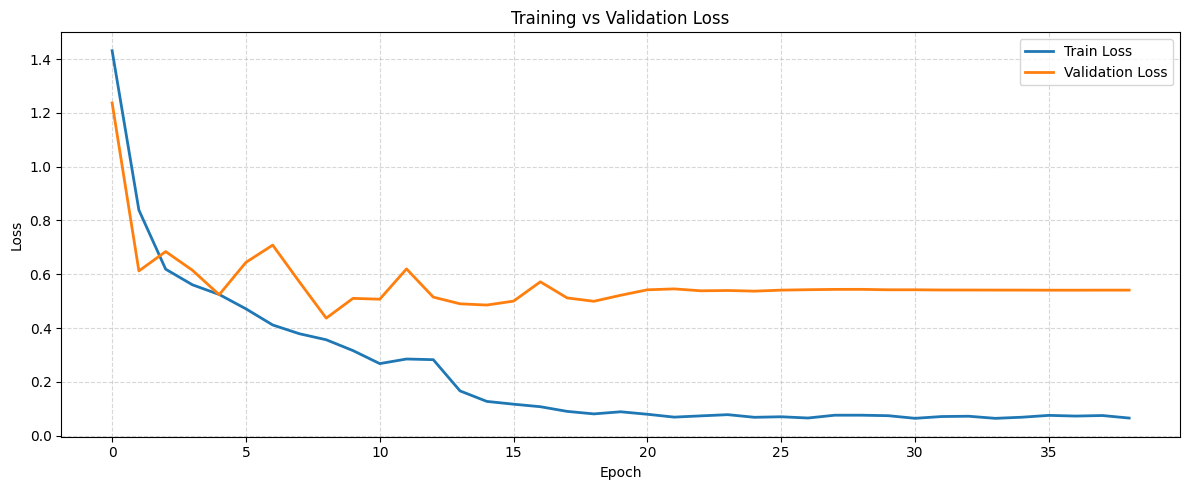

In [63]:
train_loss = [epoch["loss"] for epoch in log_history]
val_loss = [epoch["val_loss"] for epoch in log_history]

plt.figure(figsize=(12, 5))
plt.plot(train_loss, label="Train Loss", linewidth=2)
plt.plot(val_loss, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curve.png", dpi=300)
plt.show()

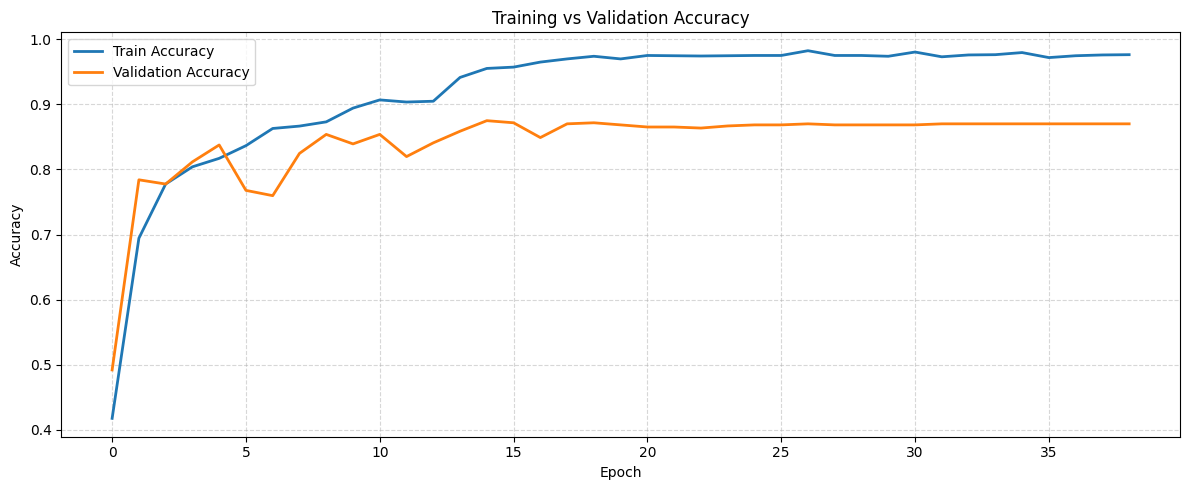

In [64]:
train_acc = [epoch["accuracy"] for epoch in log_history]
val_acc = [epoch["val_accuracy"] for epoch in log_history]

plt.figure(figsize=(12, 5))
plt.plot(train_acc, label="Train Accuracy", linewidth=2)
plt.plot(val_acc, label="Validation Accuracy", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/acc_curve.png", dpi=300)
plt.show()

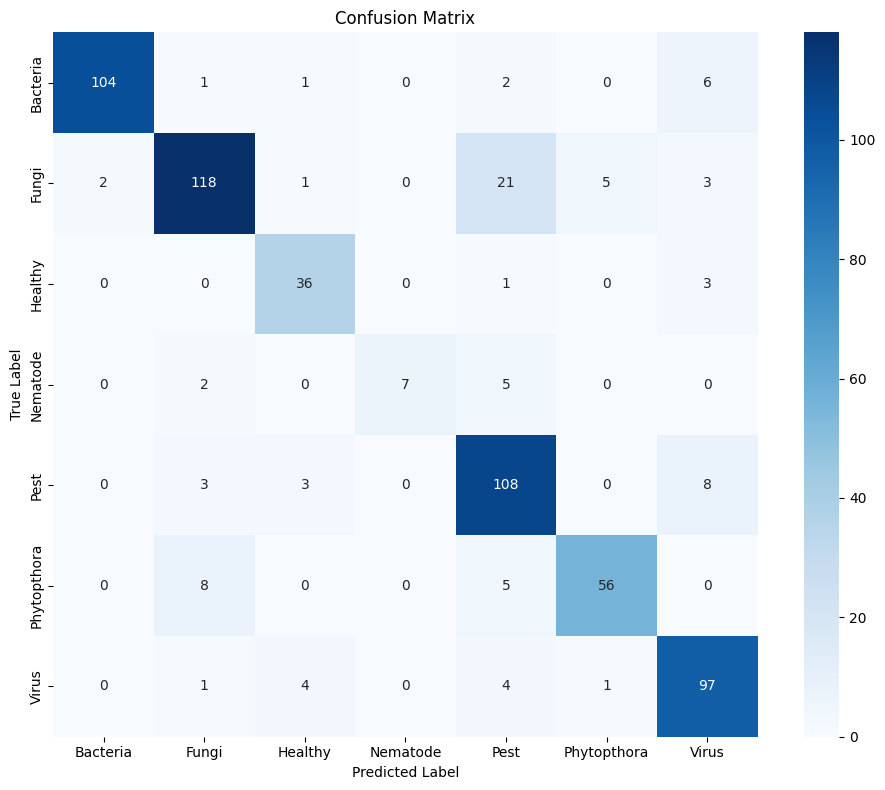

In [65]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    square=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=300)
plt.show()